# Strategy Testing
In this notebook various tests are ran on mockups to explain the process behind implementing the strategy. Such functions implemented to aid the strategy are the rolling z-score and signal generator in [`strategy.py`](../src/strategy.py).

## Rolling Z-score
In this function we aim to compute the z-score using a rolling mean and rolling standard deviation. This allows us to account for only knowing information at the previous states and not using look-ahead bias. In order to test this we create a mean-reverting series to act as our test spread, and run the rolling_zscore function on this. We expect that the mean should be close to zero since all the z-scores describe the mean-reversion of the series. Furthermore, we expect a standard deviation of around one and a min or max of around ±2-3.

In [29]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
import numpy as np
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent # parent dir
sys.path.insert(0,str(project_root/"src"))
from strategy import rolling_zscore, generate_signals_stateless, generate_signals_stateful
from backtester import extract_trades, run_backtest, compute_returns_series, run_backtest_walkforward, compute_pnl, compute_pnl_walkforward
from cointegration import engle_granger_test
from data_loader import download_prices

np.random.seed(42)
n = 1000
phi = 0.9
ar = np.zeros(n)
shocks = np.random.normal(0, 1, n)
for i in range(1, n):
    ar[i] = phi * ar[i-1] + shocks[i]
spread = pd.Series(ar)

z = rolling_zscore(spread, window=60)

print(z.describe())



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
count    941.000000
mean       0.067436
std        1.126697
min       -2.901968
25%       -0.721996
50%        0.002709
75%        0.834848
max        2.963693
dtype: float64


Next, we plot the z-score and spread to confirm that the z-score seems to cross ±2 when the spread stretches, and zero when the spread reverts.

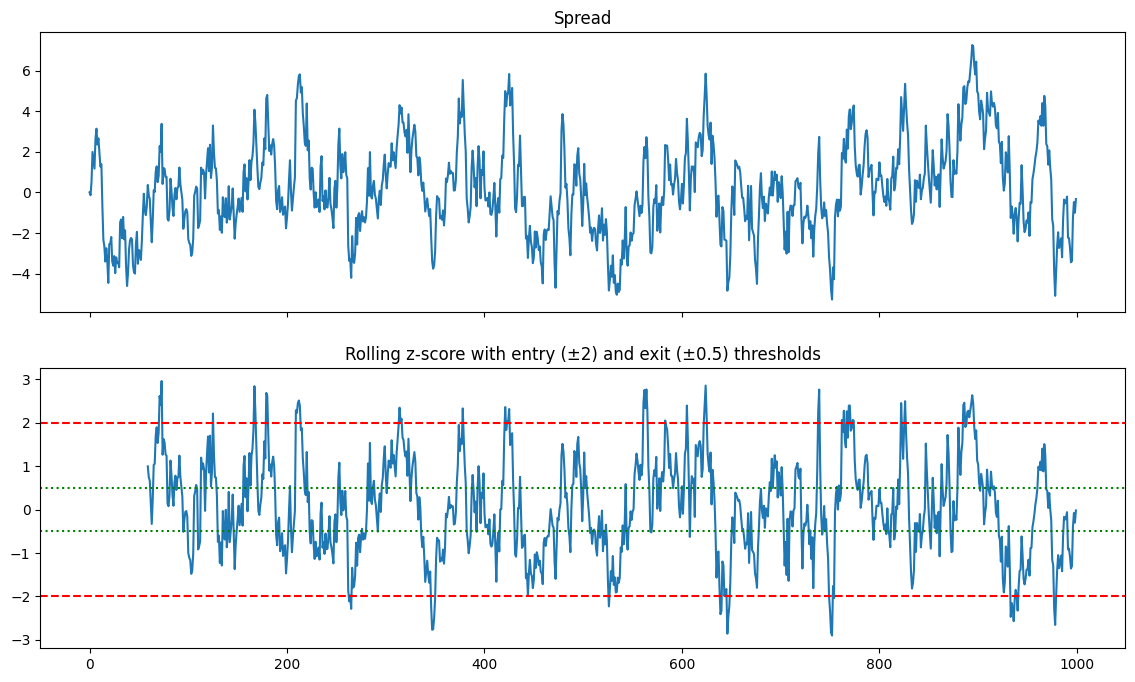

In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(spread); ax1.set_title('Spread')
ax2.plot(z); ax2.axhline(2, color='r', ls='--'); ax2.axhline(-2, color='r', ls='--')
ax2.axhline(0.5, color='g', ls=':'); ax2.axhline(-0.5, color='g', ls=':')
ax2.set_title('Rolling z-score with entry (±2) and exit (±0.5) thresholds')
plt.show()

Using the rolling_zscore function along with our stateless signal generator, we can also check the proportions of short entries, long entries, and flat segments. This allows for a basic sanity check where we can eyeball the generator at work. We note that since this generator is stateless, the regions between entry and exit thresholds are considered ambigous. This is because the generator does not hold information regarding if we are holding a short or long position.

In [31]:
# Load EWA/EWC, get the spread from the hedge ratio
prices = download_prices(['EWA', 'EWC'], '2015-01-01', '2024-12-31')
eg = engle_granger_test(prices['EWA'], prices['EWC'])
spread = eg['residuals']

z = rolling_zscore(spread, window=60)
signals_stateless = generate_signals_stateless(z)

# How many entry signals?
print(f"Long-spread entries: {(signals_stateless == 1).sum()}")
print(f"Short-spread entries: {(signals_stateless == -1).sum()}")
print(f"Flat: {(signals_stateless == 0).sum()}")

Long-spread entries: 141
Short-spread entries: 148
Flat: 2226


We can also compare these results to the implemented stateful signal generator. We expect that there should be less flat days since it will be holding at some of those positions. This also means we expect more long-spread and short-spread days.

In [32]:
signals_stateful = generate_signals_stateful(z)

# How many entry signals?
print(f"Long-spread entries: {(signals_stateful == 1).sum()}")
print(f"Short-spread entries: {(signals_stateful == -1).sum()}")
print(f"Flat: {(signals_stateful == 0).sum()}")

Long-spread entries: 458
Short-spread entries: 508
Flat: 1549


Moreover, we can plot the stateful and stateless signals on top of the z-scores. This will allow a visual confirmation that we are entering and exiting position at the proper z-score thresholds.

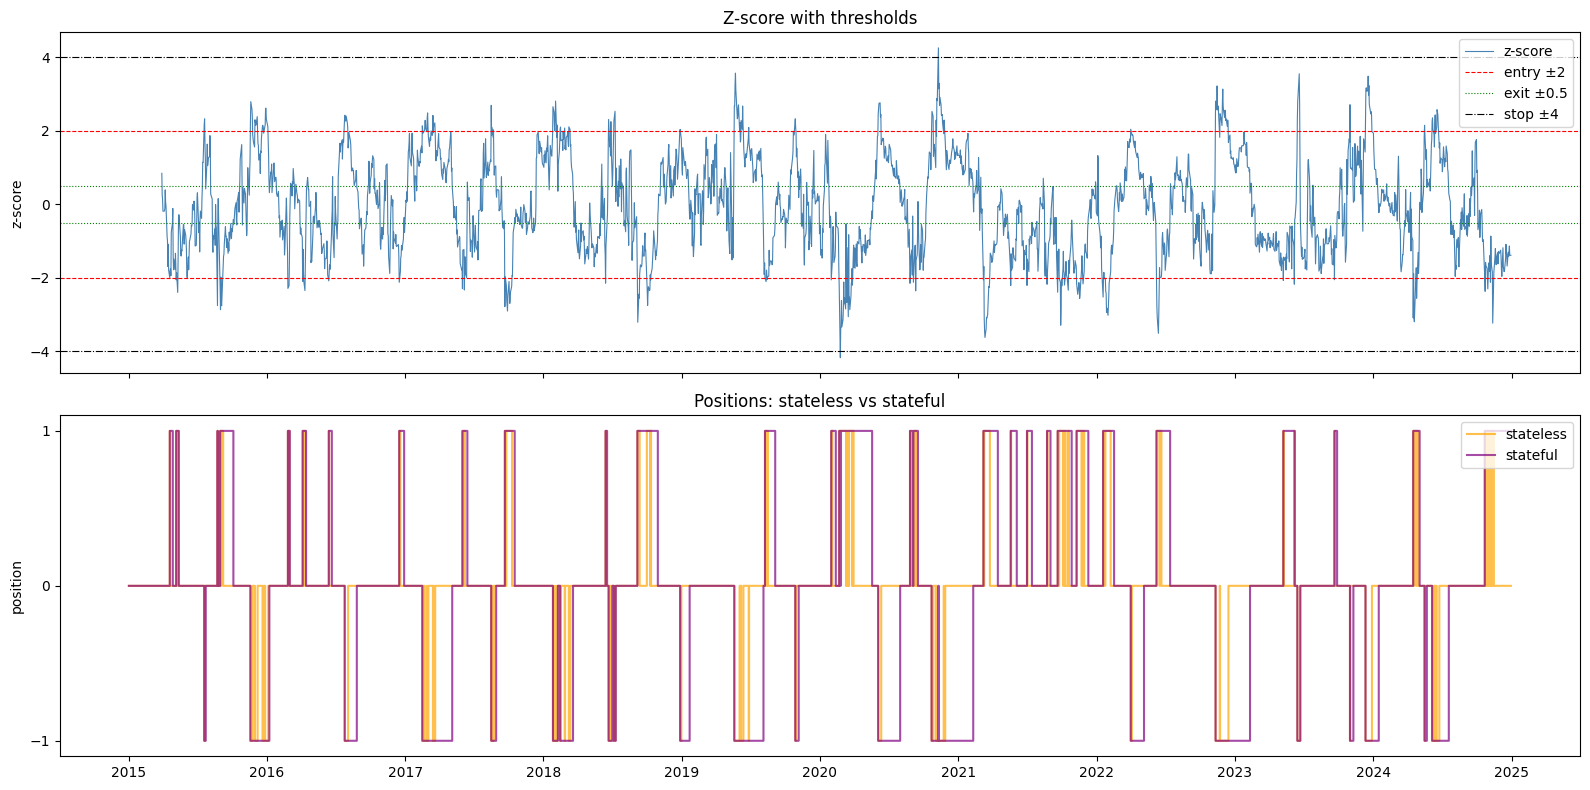

In [33]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top panel: z-score with threshold lines
ax1.plot(z, color='steelblue', lw=0.8, label='z-score')
ax1.axhline(2, color='red', ls='--', lw=0.8, label='entry ±2')
ax1.axhline(-2, color='red', ls='--', lw=0.8)
ax1.axhline(0.5, color='green', ls=':', lw=0.8, label='exit ±0.5')
ax1.axhline(-0.5, color='green', ls=':', lw=0.8)
ax1.axhline(4, color='black', ls='-.', lw=0.8, label='stop ±4')
ax1.axhline(-4, color='black', ls='-.', lw=0.8)
ax1.set_ylabel('z-score')
ax1.legend(loc='upper right')
ax1.set_title('Z-score with thresholds')

# Bottom panel: both position series
ax2.step(signals_stateless.index, signals_stateless, where='post',
         color='orange', alpha=0.7, label='stateless')
ax2.step(signals_stateful.index, signals_stateful, where='post',
         color='purple', alpha=0.7, label='stateful')
ax2.set_ylabel('position')
ax2.set_yticks([-1, 0, 1])
ax2.legend(loc='upper right')
ax2.set_title('Positions: stateless vs stateful')

plt.tight_layout()
plt.show()

In [34]:
z = rolling_zscore(spread, window=60)
sig = generate_signals_stateful(z)

# Find where z crossed the stop
stop_dates = z[(z < -4) | (z > 4)].index
print("Dates where |z| > 4:")
for d in stop_dates:
    print(f"{d.date()}  z={z[d]:.2f}  position={sig[d]}")

Dates where |z| > 4:
2020-02-24  z=-4.18  position=0
2020-11-09  z=4.25  position=0


We can also find the exact dates where the stop loss was triggered. In Febuary 2020 COVID-19 caused a widespread global supply chain disruption - greatly damaging the trust in markets. On the other hand, November 2020 was when the news of a vaccine was announced, leading many to believe recovery was imminent in the global economy.

## Extracting Trades
In this part we run a function designed to follow the positions array generated from the stateful signal generator. This function, `extract_trades` returns a DataFrame containing the entry and exit dates, position type (short, long),  holding period, and if the trade has not been closed it flags is using the still_open column.

In [35]:
z = rolling_zscore(spread, window=60)
positions = generate_signals_stateful(z)
trades = extract_trades(positions)

completed = trades[trades['still_open']==False]
print(f"Completed trades: {len(completed)}")
print(f"Avg holding period: {completed['holding_period'].mean():.1f} bars")
print(f"Long / short: {(completed['direction']==1).sum()} / {(completed['direction']==-1).sum()}")

Completed trades: 51
Avg holding period: 18.0 bars
Long / short: 29 / 22


Importantly, the average holding period of 18 days lines up exactly with our predicted half life of 14.6 days for the EWA/EWC pair in sample.

## Backtest In-sample and Out-of-sample
In this segment, we wish to backtest our strategy with the pair EWA, EWC. We note that since this pair was cointegrated on the 2015-2020 (in-sample) window we expect positive trends in the equity curve. On the other hand, the out-of-sample 2021-2024 window found that this pair suffered a regime change and were no longer cointegrated, thus we expect the equity curve to be more sporadic or negative.

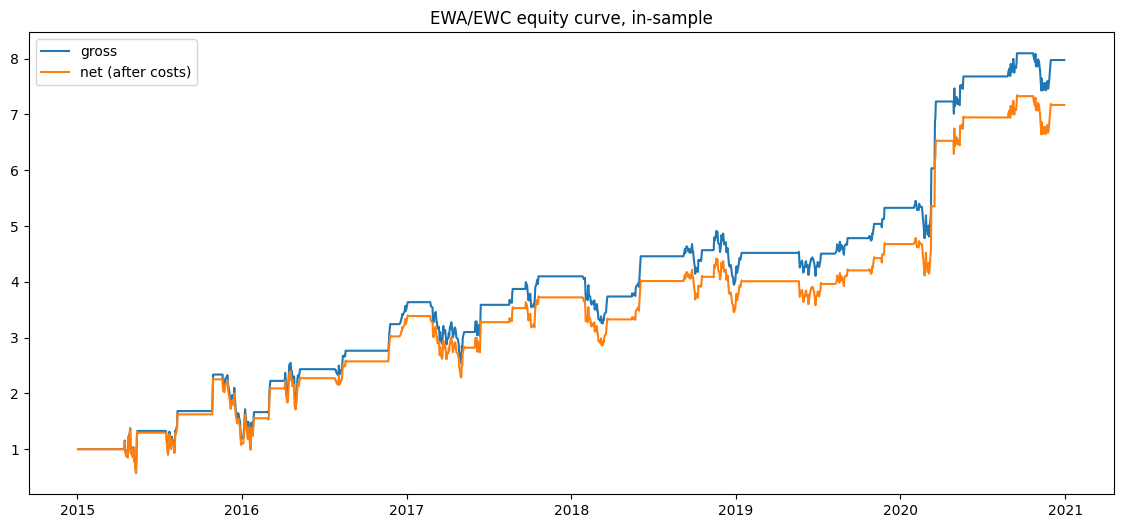

Final gross: 7.9755
Final net:   7.1701


In [36]:
# In-sample window, in-sample beta
prices_is = download_prices(['EWA', 'EWC'], '2015-01-01', '2020-12-31')
eg = engle_granger_test(prices_is['EWA'], prices_is['EWC'])
beta_is = eg['beta']

result = run_backtest(prices_is, 'EWA', 'EWC', beta_is, cost_bps=5.0)
eq = result['equity_curve']

plt.figure(figsize=(14,6))
plt.plot(eq['cum_gross'], label='gross')
plt.plot(eq['cum_net'], label='net (after costs)')
plt.legend(); plt.title('EWA/EWC equity curve, in-sample'); plt.show()

print(f"Final gross: {eq['cum_gross'].iloc[-1]:.4f}")
print(f"Final net:   {eq['cum_net'].iloc[-1]:.4f}")

Note the positive trend in the above in-sample equity curve.

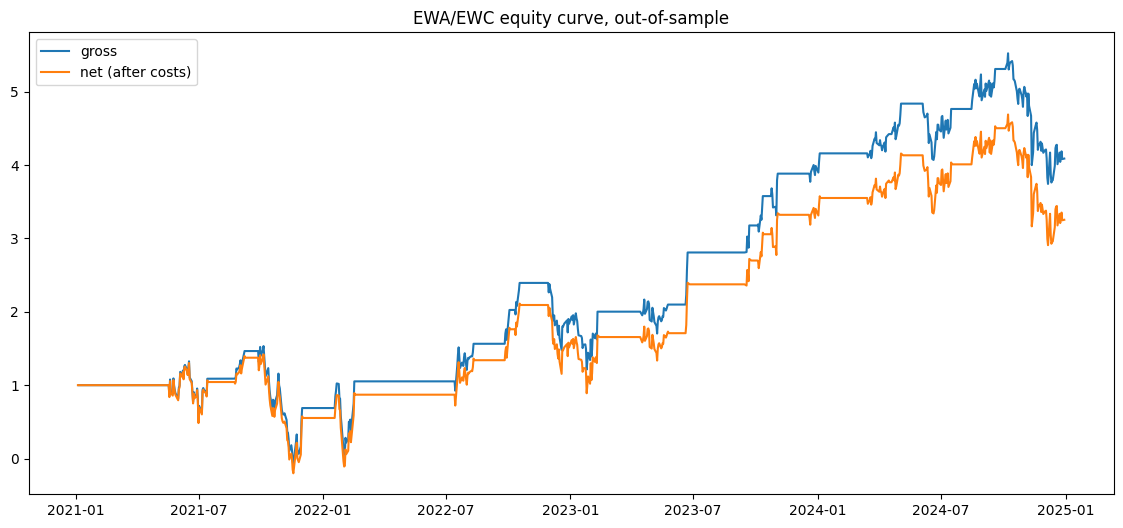

Final gross: 4.0894
Final net:   3.2548


In [37]:
# Apply frozen beta to out-of-sample prices
prices_oos = download_prices(['EWA', 'EWC'], '2021-01-01', '2024-12-31')
result_oos = run_backtest(prices_oos, 'EWA', 'EWC', beta_is, cost_bps=5.0)

eq_oos = result_oos['equity_curve']

plt.figure(figsize=(14,6))
plt.plot(eq_oos['cum_gross'], label='gross')
plt.plot(eq_oos['cum_net'], label='net (after costs)')
plt.legend(); plt.title('EWA/EWC equity curve, out-of-sample'); plt.show()

print(f"Final gross: {eq_oos['cum_gross'].iloc[-1]:.4f}")
print(f"Final net:   {eq_oos['cum_net'].iloc[-1]:.4f}")

Suprisingly, even with the failed cointegration in the out-of-sample range, the given pair still produced a profitable trend. This implies that the EWA, EWC p-value of 0.20 provided insufficient evidence of cointegration, not absence of mean-reversion behaiviours. Other aspects of the relationship did weaken out-of-sample, half-life went from 14-44 days signalling reversion slowing. We also have much weaker gross and net results than the in-sample. This example illustrates how cointegration tests are highly conservative barriers: economic relationships can still persist in weaker forms without absolute cointegrastion.

## Break Even Costs

The arbitrary costs serve as no real metric on their own. In order to have a thorough understanding of the profitability of a strategy, it is essential to understand at what point the strategy refuses to remain positive. It is for this purpose that we test various values for `cost_bps` until we determine the cost that breaks the feasibility of the strategy.

In [38]:
for bps in range(0,100):
    result_costs = run_backtest(prices_is, 'EWA', 'EWC', beta_is, cost_bps=bps)
    final_net = result_costs['equity_curve']['cum_net'].iloc[-1]
    if final_net <= 0:    
        print(f"cost_bps={bps:4d}  final net P&L={final_net:.4f}")
        break

cost_bps=  50  final net P&L=-0.0776


From this we can see that a cost of 50 bps is required to break the profitability of the strategy.

## Normalized returns

Next we wish to construct normalized returns for the strategy. This is done by dividing the net profit and loss by a fixed capital amount. By normalizing the returns we obtain a unit free representation of this strategies performance.

In [39]:
result = run_backtest(prices_is, 'EWA', 'EWC', beta_is, cost_bps=5.0)
positions = result['positions']
eq = result['equity_curve']
net_pnl = eq['net_pnl']          # net of transaction costs

# Capital deployed = |position| * two-leg notional, averaged over days in a trade
two_leg = (prices_is['EWA'] + beta_is * prices_is['EWC']).abs()
in_trade = positions.abs() > 0
capital = (positions.abs() * two_leg)[in_trade].mean()

ret = compute_returns_series(net_pnl, capital)

n_years = len(positions) / 252
annualized = (1 + ret['total_return']) ** (1 / n_years) - 1

print(f"Capital base:      ${ret['capital_used']:.2f}")
print(f"Total return:       {ret['total_return']*100:.1f}%  over {n_years:.1f} years")
print(f"Annualized return:  {annualized*100:.1f}%")

Capital base:      $31.34
Total return:       21.2%  over 6.0 years
Annualized return:  3.3%


Normalized to return on allocated capital the in-sample strategy returns 3.3% annually. This is a modest but realistic gain for an unlevered pair. Given the recency of the sample period, it could be true that the pairs-trading strategy became common place which dissolved the edge present in such a pair.

## Comparing sizing modes

Next we add complexity to the sizing of positions. This is done through a 'unit' mode which only uses ±1 units of spread. The 'dollar' mode runs a dollar neutral allocation where a target notional is divided by the two leg price to determine how many units of spread can be traded. Lastly, the 'vol' mode runs a volatility sizing schema where a target daily volatility is set alongside a window. These parameters determine the units by dividing the target daily volatility by the volatility of the spread. The advantage to the larger complexity of this third option is that more volatile spreads are traded less.

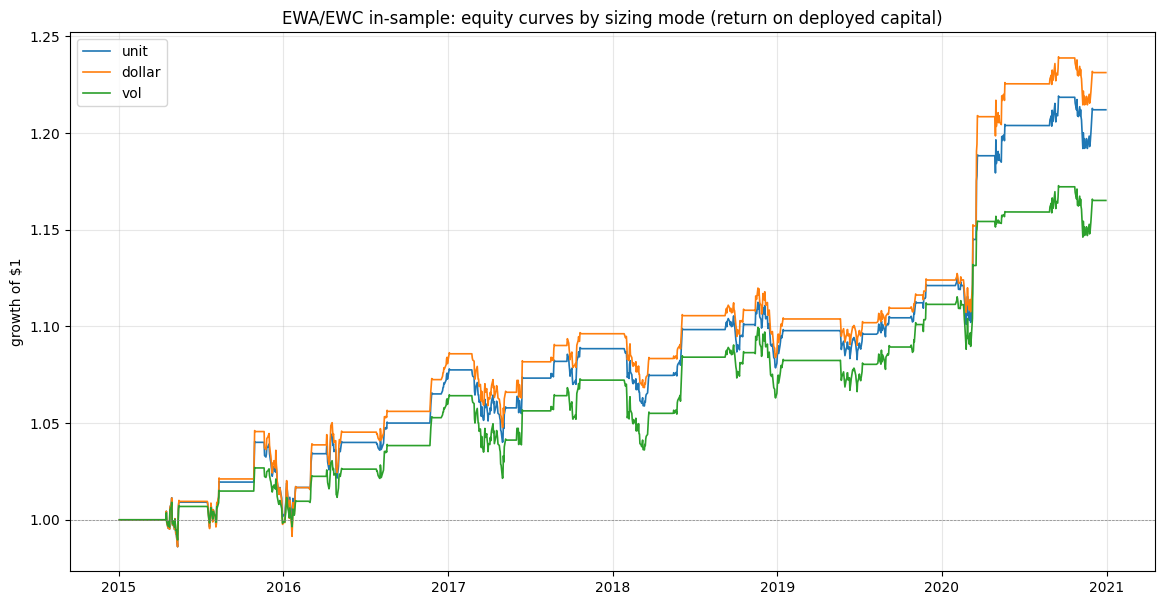

unit     capital=$        31  total return=  21.2%  Sharpe=0.83
dollar   capital=$    10,000  total return=  23.1%  Sharpe=0.85
vol      capital=$    29,542  total return=  16.5%  Sharpe=0.72


In [40]:
fig, ax = plt.subplots(figsize=(14, 7))

two_leg = (prices_is['EWA'] + beta_is * prices_is['EWC']).abs()

summary = []
for mode in ['unit', 'dollar', 'vol']:
    result = run_backtest(prices_is, 'EWA', 'EWC', beta_is, cost_bps=5.0, sizing=mode)
    positions = result['positions']
    net_pnl = result['equity_curve']['net_pnl']

    # Each mode deploys a different amount of capital, so normalize by its own
    # average deployed notional. This puts the three curves on a comparable scale.
    in_trade = positions.abs() > 0
    capital = (positions.abs() * two_leg)[in_trade].mean()

    ret = compute_returns_series(net_pnl, capital)
    ax.plot(ret['cum_return'], label=mode, linewidth=1.2)

    daily = ret['daily_return']
    sharpe = (daily.mean() / daily.std()) * np.sqrt(252)
    summary.append((mode, capital, ret['total_return'], sharpe))

ax.set_title('EWA/EWC in-sample: equity curves by sizing mode (return on deployed capital)')
ax.set_ylabel('growth of $1')
ax.axhline(1.0, color='gray', lw=0.5, ls='--')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

for mode, cap, tot, sharpe in summary:
    print(f"{mode:7s}  capital=${cap:10,.0f}  total return={tot*100:6.1f}%  Sharpe={sharpe:.2f}")

Interestingly, volatility targeting produced a lower Sharpe out of all three sizing options. The cause of this is the continuous rebalancing occurring from the position size changing. This is due to the fact that the position size is a function of the rolling volatility. This causes the backtest to incur large transaction costs on every day a position is held rather than entry and exit. It is for this reason that volatility targeting systems use rebalance bands (adjusting only when the position drifts beyond a certain threshold) rather than rebalancing daily.

## Walk-forward vs frozen beta

Instead of keeping a single beta for the entire period, walk-forward re-estimates
the hedge ratio on a trailing 252-bar window, refitting every 21 bars and holding
the estimate constant in between. Each beta is fitted strictly on data preceding
the bar it is applied to, so no future information enters the decision. This is
closer to how the strategy would actually be run, since a desk refits its models
on recent data rather than using a ratio computed years earlier.

One detail matters for a fair comparison: walk-forward needs a full lookback of
history before it can produce its first beta. Run on the out-of-sample slice alone,
its first year would be a dead warm-up while the frozen strategy traded throughout.
We therefore run both over the full 2015-2024 history so the warm-up is consumed
in-sample, then slice both to the same out-of-sample window before comparing.

beta range over OOS: 0.115 to 0.796
beta mean over OOS:  0.570   (frozen in-sample beta = 0.729)
distinct beta values: 49


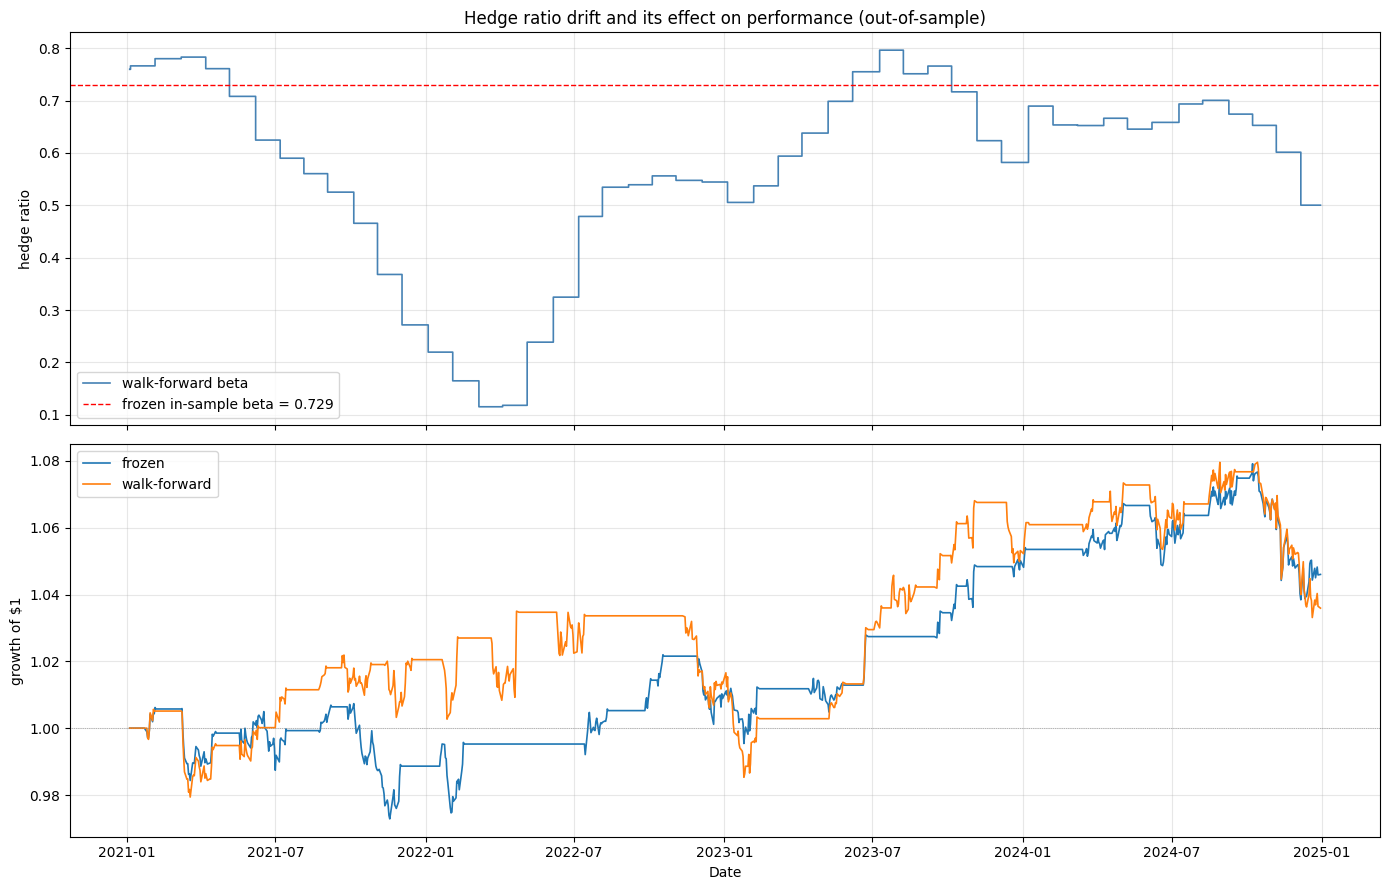

frozen         capital=$   46.66  total return=   4.6%  Sharpe=0.37
walk-forward   capital=$   40.96  total return=   3.6%  Sharpe=0.25


In [41]:
# Full history so the walk-forward warm-up is consumed before the OOS window
prices_full = download_prices(['EWA', 'EWC'], '2015-01-01', '2024-12-31')

result_frozen_full = run_backtest(prices_full, 'EWA', 'EWC', beta_is,
                                  cost_bps=5.0, sizing='unit')
result_wf_full = run_backtest_walkforward(prices_full, 'EWA', 'EWC',
                                          lookback=252, refit_every=21,
                                          cost_bps=5.0, sizing='unit')

betas_full = result_wf_full['betas']
oos = slice('2021-01-01', '2024-12-31')

# --- Hedge ratio drift ---
print(f"beta range over OOS: {betas_full[oos].min():.3f} to {betas_full[oos].max():.3f}")
print(f"beta mean over OOS:  {betas_full[oos].mean():.3f}   (frozen in-sample beta = {beta_is:.3f})")
print(f"distinct beta values: {betas_full[oos].nunique()}")

# --- Returns for each approach, sliced to the same OOS window ---
summary = []
for label, res, beta_used in [
    ('frozen', result_frozen_full, beta_is),
    ('walk-forward', result_wf_full, betas_full),
]:
    positions = res['positions'][oos]
    net_pnl = res['equity_curve']['net_pnl'][oos]

    two_leg = (prices_full['EWA'] + beta_used * prices_full['EWC']).abs()[oos]
    in_trade = positions.abs() > 0
    capital = (positions.abs() * two_leg)[in_trade].mean()

    ret = compute_returns_series(net_pnl, capital)
    daily = ret['daily_return']
    sharpe = (daily.mean() / daily.std()) * np.sqrt(252)
    summary.append((label, ret, sharpe))

# --- Two-panel figure: beta drift above, equity curves below ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.plot(betas_full[oos], drawstyle='steps-post', color='steelblue', lw=1.2,
         label='walk-forward beta')
ax1.axhline(beta_is, color='red', ls='--', lw=1.0,
            label=f'frozen in-sample beta = {beta_is:.3f}')
ax1.set_ylabel('hedge ratio')
ax1.set_title('Hedge ratio drift and its effect on performance (out-of-sample)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

for label, ret, _ in summary:
    ax2.plot(ret['cum_return'], lw=1.2, label=label)
ax2.axhline(1.0, color='gray', lw=0.5, ls=':')
ax2.set_ylabel('growth of $1')
ax2.set_xlabel('Date')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for label, ret, sharpe in summary:
    print(f"{label:13s}  capital=${ret['capital_used']:8,.2f}  "
          f"total return={ret['total_return']*100:6.1f}%  Sharpe={sharpe:.2f}")

From these results we see that the walk-forward still falls behind the frozen beta slightly (3.6% vs 4.6%). This is likely due to poor estimation of beta on the out-of-sample period - where the p-value was 0.20. We also note that this result is understated since changing beta throughout does not incur rebalancing costs in this model.